In [1]:
# os 환경 변수 GEMINI API KEY 입력
from dotenv import load_dotenv

load_dotenv()

True

### Model & Tool 정의

In [9]:
from langchain.chat_models import init_chat_model
from langchain.messages import HumanMessage
from langgraph.types import interrupt
from langgraph.types import Command
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from langchain.messages import SystemMessage

from langchain.tools import tool
from typing import Literal
from pydantic import BaseModel, Field
from langchain.messages import AIMessage


# Multi-Agent (Supervisor - 중앙 집중형)
[공식 문서](https://docs.langchain.com/oss/python/langchain/multi-agent)

## Model 정의

In [3]:
from langchain.chat_models import init_chat_model

model = init_chat_model("gpt-5-nano")

## State 정의

In [4]:
from langchain.messages import AnyMessage
from typing_extensions import TypedDict, Annotated
from langgraph.graph.message import add_messages

class TeamState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

In [18]:
# 감독관이 내릴 수 있는 결정 목록
class RouteResponse(BaseModel):
    next_step: Literal[ "researcher", "writer", "FINISH"] = Field(
        description="다음 작업을 수행할 팀원을 선택하거나, 모든 작업이 완료되었으면 FINISH를 선택"
    )
    reason: str = Field(description="선택한 이유")

In [19]:
supervisor_agent = model.with_structured_output(RouteResponse)

## Node 정의

### Supervisor Node

In [20]:
def supervisor_node(state: TeamState):
    print("\n👔 [Supervisor] 다음 작업자 결정 중...")

    # 1. 현재까지의 대화 내용을 보고 판단
    system_prompt = """
    당신은 블로그 작성 팀의 관리자입니다.
    1. 사용자 요청이 들어오면 'researcher'에게 조사를 시키세요.
    2. 조사 결과가 나오면 'writer'에게 글 작성을 시키세요.
    3. 글 작성이 완료되면 'FINISH'를 선언하세요.
    """

    # LLM에게 판단 요청
    messages = [SystemMessage(content=system_prompt)] + state["messages"]
    decision = supervisor_agent.invoke(messages)

    # 2. 판단 결과에 따라 라우팅 (Command Goto)
    messages = [SystemMessage(content=system_prompt)] + state["messages"]

    # 3. LLM에게 판단 요청 (앞서 정의한 RouteResponse 구조로 정확히 반환됩니다)
    decision = supervisor_agent.invoke(messages)

    print(f"👉 [지시] {decision.next_step} (이유: {decision.reason})")

    # 4. 판단 결과에 따라 Command(goto=...)를 이용해 다음 노드로 직행(라우팅)시킵니다.
    if decision.next_step == "FINISH":
        return Command(goto=END)
    else:
        return Command(goto=decision.next_step)


### Worker Node

In [21]:
# [팀원 1] 검색 담당 (Researcher)
def researcher_node(state: TeamState):
    print("\n🔎 [Researcher] LLM이 자료를 조사/생성 중입니다...")

    # 시스템 프롬프트 부여
    system_msg = SystemMessage(content="""
    당신은 IT 트렌드 전문 리서처입니다.
    사용자의 요청 주제에 대해 핵심 트렌드, 기술 용어, 통계 등을 포함하여
    전문적인 조사 보고서를 3줄 요약 형태로 작성하세요.
    """)

    # 이전 대화 내용 + 내 역할(System)을 합쳐서 LLM에게 전달
    # state["messages"] 안에 사용자의 요청이 들어있음
    messages = [system_msg] + state["messages"]

    # LLM 실행
    response = model.invoke(messages)

    # 결과 반환 (name을 지정해야 감독관이 누가 말했는지 앎)
    return Command(
        update={"messages": [AIMessage(content=response.content, name="Researcher")]},
        goto="supervisor"
    )


In [22]:
# [팀원 2] 집필 담당 (Writer)
def writer_node(state: TeamState):
    print("\n✍️ [Writer] LLM이 블로그 포스팅을 작성 중입니다...")

    system_msg = SystemMessage(content="""
    당신은 테크 블로그 전문 작가입니다.
    위의 대화 내역에 있는 'Researcher'의 조사 결과를 바탕으로
    매력적인 블로그 포스팅(제목+본문)을 작성하세요.
    이모지를 적절히 사용하여 가독성을 높이세요.
    """)

    # 공유된 대화 기록(Researcher의 결과 포함)을 다 같이 넘겨줌
    messages = [system_msg] + state["messages"]

    response = model.invoke(messages)

    return Command(
        update={"messages": [AIMessage(content=response.content, name="Writer")]},
        goto="supervisor"
    )


## 그래프 생성

In [23]:
workflow = StateGraph(TeamState)

workflow.add_node("supervisor", supervisor_node)
workflow.add_node("researcher", researcher_node)
workflow.add_node("writer", writer_node)

workflow.add_edge(START, "supervisor")

In [24]:
from langgraph.checkpoint.memory import InMemorySaver

checkpointer = InMemorySaver()

In [25]:
app = workflow.compile(checkpointer=checkpointer)

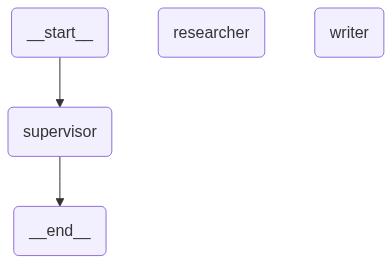

In [26]:
app

In [27]:
config = {"configurable": {"thread_id": "team-blog-1"}}

In [28]:
app.invoke(
    {"messages": [HumanMessage(content="AI 최신 트렌드에 대해 블로그 글 써줘")]},
    config=config
)


👔 [Supervisor] 다음 작업자 결정 중...


/Users/dohyunkim/Documents/langchain-study/langchain/.venv/lib/python3.13/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=RouteResponse(next_step='...을 제시합니다.'), input_type=RouteResponse])
  return self.__pydantic_serializer__.to_python(
/Users/dohyunkim/Documents/langchain-study/langchain/.venv/lib/python3.13/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=RouteResponse(next_step='... 진행하기 위함.'), input_type=RouteResponse])
  return self.__pydantic_serializer__.to_python(


👉 [지시] researcher (이유: 요청에 따라 AI 최신 트렌드에 대해 조사하고 수집된 정보를 바탕으로 글 작성을 진행하기 위함.)

🔎 [Researcher] LLM이 자료를 조사/생성 중입니다...

👔 [Supervisor] 다음 작업자 결정 중...


/Users/dohyunkim/Documents/langchain-study/langchain/.venv/lib/python3.13/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=RouteResponse(next_step='...을 요청합니다.'), input_type=RouteResponse])
  return self.__pydantic_serializer__.to_python(
/Users/dohyunkim/Documents/langchain-study/langchain/.venv/lib/python3.13/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=RouteResponse(next_step='... 정리하기 위함.'), input_type=RouteResponse])
  return self.__pydantic_serializer__.to_python(


👉 [지시] researcher (이유: 블로그 글 작성을 위해 최신 AI 트렌드에 대한 신뢰 가능한 자료를 수집하고 방향성(핵심 트렌드, 기술 용어, 실무 사례, 전망)을 정리하기 위함.)

🔎 [Researcher] LLM이 자료를 조사/생성 중입니다...

👔 [Supervisor] 다음 작업자 결정 중...


...

👉 [지시] writer (이유: 조사 결과를 바탕으로 블로그 글 작성을 시작합니다. writer 단계에서 초안 작성 및 구조화된 콘텐츠를 제공합니다.)

✍️ [Writer] LLM이 블로그 포스팅을 작성 중입니다...

👔 [Supervisor] 다음 작업자 결정 중...


/Users/dohyunkim/Documents/langchain-study/langchain/.venv/lib/python3.13/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=RouteResponse(next_step='...완료되었습니다.'), input_type=RouteResponse])
  return self.__pydantic_serializer__.to_python(


👉 [지시] FINISH (이유: 작업 완료: Writer가 AI 최신 트렌드에 관한 블로그 글 작성을 마쳤습니다. 추가 보완이나 특정 분야의 사례 연구가 필요하면 요청해 주세요.)


/Users/dohyunkim/Documents/langchain-study/langchain/.venv/lib/python3.13/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=RouteResponse(next_step='... 요청해 주세요.'), input_type=RouteResponse])
  return self.__pydantic_serializer__.to_python(


{'messages': [HumanMessage(content='AI 최신 트렌드에 대해 블로그 글 써줘', additional_kwargs={}, response_metadata={}, id='b9ae1c9d-578a-4b23-9835-9059863ddb6a'),
  AIMessage(content='AI 최신 트렌드 3줄 요약:\n- 핵심 트렌드: 생성형 AI의 기업 생산성 증대와 산업 맞춤화 확산, 멀티모달 모델의 업무 도구화, 에지 컴퓨팅과 프라이버시를 고려한 데이터 거버넌스 강화, 안전성·거버넌스 중심의 규제 대응 및 MLOps를 통한 모델 운영 자동화 증가.\n- 기술 용어 핵심: Foundation Models(FMs), Large Language Models(LLMs), RLHF, RAG, 프롬프트 엔지니어링, 멀티모달(diffusion 포함) 모델, LoRA/어댑터 파인튜닝, 양자화/모델 축소, 온디바이스 AI, 연합학습, 정책/거버넌스 as code.\n- 통계 및 전망: 글로벌 AI 지출은 2023년 이후 두 자릿수 성장세를 보였고, 다수 분석가가 CAGR 20–30%대의 성장 전망을 제시하며, 엔터프라이즈 도입 확대와 생산성 향상 사례가 지속 보고되고 있음.', additional_kwargs={}, response_metadata={}, name='Researcher', id='9ca10c3c-c180-43ec-a374-02347368a63b', tool_calls=[], invalid_tool_calls=[]),
  AIMessage(content='AI 최신 트렌드의 핵심은 생성형 AI로 인한 기업 생산성 증대와 산업 맞춤화의 확산, 멀티모달 도구화, 에지 컴퓨팅 기반 데이터 거버넌스 강화와 안전성·거버넌스 규제 대응의 중요성이다.\n\n주요 기술 용어로는 Foundation Models(FMs), Large Language Models(LLMs), RLHF, RAG, 프롬프트 엔지니어링, 멀티모달 모델, LoRA/어댑터 파인튜닝, 

새로운 작업자 '검수자'를 추가한다면 어떻게 구현하면 될까?

# Multi-Agent (Handoff (Network))
[LangGraph 공식 문서](https://docs.langchain.com/oss/python/langchain/multi-agent/handoffs)

[OpenAI Handoff](https://openai.github.io/openai-agents-python/handoffs/)

## Model&Tool 정의

In [29]:
from langchain.chat_models import init_chat_model

model = init_chat_model("gpt-5-nano")

[tool runtime](https://reference.langchain.com/python/langgraph/agents/?h=toolruntime#langgraph.prebuilt.tool_node.InjectedStore)

In [31]:
from langgraph.types import Command
from langchain.messages import ToolMessage
from langchain.tools import ToolRuntime

@tool
def transfer_to_tech_support(runtime: ToolRuntime):
    """기술적인 문제(컴퓨터, 코드, 에러 등)를 해결해야 할 때 이 도구를 사용하여 기술팀으로 연결하세요."""

    # runtime.tool_call_id로 현재 도구 호출 ID에 안전하게 접근
    tool_id = runtime.tool_call_id
    print(f"   [System] 기술 지원팀으로 이동합니다... (Tool Call ID: {tool_id})")

    # Command를 반환하여 상태를 업데이트하고 tech_support 노드로 점프(Hand-off)
    return Command(
        update={
            "messages": [
                ToolMessage(
                    content="기술 지원팀으로 성공적으로 연결되었습니다.",
                    tool_call_id=tool_id # runtime에서 꺼낸 ID 매핑
                )
            ]
        },
        goto="tech_support"
    )



In [47]:
@tool
def transfer_to_billing(runtime: ToolRuntime):
    """환불, 결제, 금액 관련 문제를 해결해야 할 때 이 도구를 사용하여 환불팀으로 연결하세요."""
    tool_id = runtime.tool_call_id

    return Command(
    update={
        "messages": [
            ToolMessage(
                content="환불/결제팀으로 성공적으로 연결되었습니다.",
                tool_call_id=tool_id
            )
        ]
    },
    goto="billing"
)



In [48]:
@tool
def transfer_to_reception(runtime: ToolRuntime):
    """일반적인 문의거나, 인사가 끝났으면 안내 데스크로 다시 연결하세요."""
    tool_id = runtime.tool_call_id

    return Command(
    update={
        "messages": [
            ToolMessage(
                content="안내 데스크로 복귀했습니다.",
                tool_call_id=tool_id
            )
        ]
    },
    goto="receptionist"
)


## State 정의

In [49]:
from langchain.messages import AnyMessage
from typing_extensions import TypedDict, Annotated
from langgraph.graph.message import add_messages

class AgentState(TypedDict):
      messages: Annotated[list[AnyMessage], add_messages]

## Node 정의

### Agent Nodes

In [50]:
# [상담원 1] 안내 데스크 (시작점)
def receptionist_node(state: AgentState):
    print("\n💁 [Reception] 안녕하세요.")

    system_prompt = """
    당신은 고객센터의 친절한 안내 데스크입니다.
    1. 고객의 말을 듣고 인사하세요.
    2. '기술 문제'라면 tech_support 도구를 쓰세요.
    3. '돈/환불 문제'라면 billing 도구를 쓰세요.
    4. 그 외 잡담은 직접 답변하세요.
    """

    # 안내 데스크는 기술팀과 환불팀으로 보낼 수 있음
    tools = [transfer_to_tech_support, transfer_to_billing]
    model_with_tools = model.bind_tools(tools)

    messages = [SystemMessage(content=system_prompt)] + state["messages"]
    response = model_with_tools.invoke(messages)

    return {"messages": [response]}

In [51]:
# [상담원 2] 기술 지원팀
def tech_node(state: AgentState):
    print("\n🛠️ [Tech Support] 기술적인 문제를 해결해드립니다.")

    system_prompt = """
    당신은 베테랑 기술 지원 엔지니어입니다.
    컴퓨터 고장, 파이썬 코드 에러 등을 해결해줍니다.
    만약 고객이 '환불'을 요구하면 즉시 billing 도구를 써서 넘기세요.
    해결이 끝나면 reception으로 넘기세요.
    """

    # 기술팀은 환불팀이나 안내 데스크로 보낼 수 있음
    tools = [transfer_to_billing, transfer_to_reception]
    model_with_tools = model.bind_tools(tools)

    messages = [SystemMessage(content=system_prompt)] + state["messages"]
    response = model_with_tools.invoke(messages)

    return {"messages": [response]}

In [52]:
# [상담원 3] 환불팀
def billing_node(state: AgentState):
    print("\n💰 [Billing] 결제 및 환불 담당입니다.")

    system_prompt = """
    당신은 환불 담당자입니다.
    고객의 환불 요청을 처리해줍니다.
    기술적인 질문을 하면 tech_support로 넘기세요.
    해결이 끝나면 reception으로 넘기세요.
    """

    # 환불팀은 기술팀이나 안내 데스크로 보낼 수 있음
    tools = [transfer_to_tech_support, transfer_to_reception]
    model_with_tools = model.bind_tools(tools)

    messages = [SystemMessage(content=system_prompt)] + state["messages"]
    response = model_with_tools.invoke(messages)

    return {"messages": [response]}

## 그래프 생성

In [53]:
workflow = StateGraph(AgentState)

workflow.add_node("receptionist", receptionist_node)
workflow.add_node("tech_support", tech_node)
workflow.add_node("billing", billing_node)

In [54]:
from langgraph.prebuilt import ToolNode

# 도구를 실행할 노드 (ToolNode)
# 에이전트가 도구를 호출하면 -> Tool Node로 가서 -> 함수 실행 -> Command 반환 -> 다른 노드로 점프
all_tools = [transfer_to_tech_support, transfer_to_billing, transfer_to_reception]
tool_node = ToolNode(all_tools)

In [55]:
tool_node

tools(tags=None, recurse=True, explode_args=False, func_accepts={'config': ('N/A', <class 'inspect._empty'>), 'runtime': ('N/A', <class 'inspect._empty'>)}, _tools_by_name={'transfer_to_tech_support': StructuredTool(name='transfer_to_tech_support', description='기술적인 문제(컴퓨터, 코드, 에러 등)를 해결해야 할 때 이 도구를 사용하여 기술팀으로 연결하세요.', args_schema=<class 'langchain_core.utils.pydantic.transfer_to_tech_support'>, func=<function transfer_to_tech_support at 0x113a874c0>), 'transfer_to_billing': StructuredTool(name='transfer_to_billing', description='환불, 결제, 금액 관련 문제를 해결해야 할 때 이 도구를 사용하여 환불팀으로 연결하세요.', args_schema=<class 'langchain_core.utils.pydantic.transfer_to_billing'>, func=<function transfer_to_billing at 0x113ae4680>), 'transfer_to_reception': StructuredTool(name='transfer_to_reception', description='일반적인 문의거나, 인사가 끝났으면 안내 데스크로 다시 연결하세요.', args_schema=<class 'langchain_core.utils.pydantic.transfer_to_reception'>, func=<function transfer_to_reception at 0x113ae49a0>)}, _injected_args={'transfer_to_te

In [56]:
workflow.add_node("tools", tool_node)

In [57]:
# 시작은 안내 데스크
workflow.add_edge(START, "receptionist")

In [61]:
from langgraph.prebuilt import tools_condition

# 모든 노드는 tools 또는 END 노드 중 하나 (조건부 엣지)


# 3. 조건부 엣지 연결 (도구 호출 여부에 따라 tools 또는 END로 분기)
workflow.add_conditional_edges("receptionist", tools_condition, ["tools", END])
workflow.add_conditional_edges("tech_support", tools_condition, ["tools", END])
workflow.add_conditional_edges("billing", tools_condition, ["tools", END])

Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.


In [62]:
from langgraph.checkpoint.memory import InMemorySaver

checkpointer = InMemorySaver()

In [63]:
app = workflow.compile(checkpointer=checkpointer)

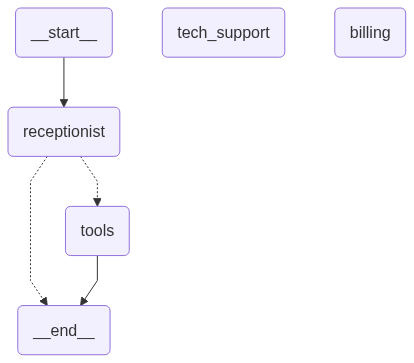

In [64]:
app

In [65]:
config = {"configurable": {"thread_id": "handoff-demo-1"}}

In [66]:
app.invoke(
    {"messages": [HumanMessage(content="제 컴퓨터 화면이 안 나와요. 고장난 것 같아요.")]},
    config=config
)


💁 [Reception] 안녕하세요.
   [System] 기술 지원팀으로 이동합니다... (Tool Call ID: call_5GforUJNQbTVcox4hax6f4xz)

🛠️ [Tech Support] 기술적인 문제를 해결해드립니다.


{'messages': [HumanMessage(content='제 컴퓨터 화면이 안 나와요. 고장난 것 같아요.', additional_kwargs={}, response_metadata={}, id='5d2bc9a3-ad1c-40b1-8c8f-c152bd3f3605'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 726, 'prompt_tokens': 283, 'total_tokens': 1009, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 704, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-EE7iXztDxLWruMwzPwCuQvGdEb95a', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a01395-8d83-7ce3-85c7-bdef6e7b27d9-0', tool_calls=[{'name': 'transfer_to_tech_support', 'args': {}, 'id': 'call_5GforUJNQbTVcox4hax6f4xz', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 283, 'output_tokens':

In [67]:
app.invoke(
    {"messages": [HumanMessage(content="아직 안 되는데, 그냥 환불하고 싶어요.")]},
    config=config
)


💁 [Reception] 안녕하세요.

💰 [Billing] 결제 및 환불 담당입니다.


{'messages': [HumanMessage(content='제 컴퓨터 화면이 안 나와요. 고장난 것 같아요.', additional_kwargs={}, response_metadata={}, id='5d2bc9a3-ad1c-40b1-8c8f-c152bd3f3605'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 726, 'prompt_tokens': 283, 'total_tokens': 1009, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 704, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-EE7iXztDxLWruMwzPwCuQvGdEb95a', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a01395-8d83-7ce3-85c7-bdef6e7b27d9-0', tool_calls=[{'name': 'transfer_to_tech_support', 'args': {}, 'id': 'call_5GforUJNQbTVcox4hax6f4xz', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 283, 'output_tokens':